<a href="https://colab.research.google.com/github/Shreyapowar9961/Deep_Learning_sem6/blob/main/Lab9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Experiment No. 09

Name : Shreya Nandkumar Powar

Class : TYDS-65

PRN : 2324001231

Github Repo :

In [ ]:
import pandas as pd
import numpy as np

dataset = pd.read_csv("RELIANCE.NS.csv")

In [ ]:
data = dataset[['Close']]

In [ ]:
data = data.dropna()

In [ ]:
data = data.values

In [ ]:
print(np.isnan(data).sum())

0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(
    feature_range=(0,1)
)

scaled_data = scaler.fit_transform(data)

In [ ]:
x_train = []
y_train = []

for i in range(60, len(scaled_data)):

    x_train.append(
        scaled_data[i-60:i,0]
    )

    y_train.append(
        scaled_data[i,0]
    )

x_train = np.array(x_train)

y_train = np.array(y_train)

In [ ]:
print(np.isnan(x_train).sum())

print(np.isnan(y_train).sum())

0
0


In [ ]:
x_train = np.reshape(
    x_train,
    (x_train.shape[0],
     x_train.shape[1],
     1)
)

In [ ]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

model = Sequential()

model.add(
    LSTM(
        units=50,
        return_sequences=True,
        input_shape=(x_train.shape[1],1)
    )
)

model.add(
    LSTM(units=50)
)

model.add(
    Dense(units=1)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - loss: 6.6160e-04 - val_loss: 0.0021
Epoch 2/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - loss: 4.3323e-05 - val_loss: 0.0018
Epoch 3/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - loss: 3.8557e-05 - val_loss: 8.5125e-04
Epoch 4/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - loss: 3.5505e-05 - val_loss: 0.0012
Epoch 5/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - loss: 3.5338e-05 - val_loss: 0.0010
Epoch 6/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - loss: 3.1201e-05 - val_loss: 8.4435e-04
Epoch 7/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - loss: 3.0309e-05 - val_loss: 6.6147e-04
Epoch 8/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - loss: 3.0715e-05 - val_loss: 0.0010
Epoch 9/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - loss: 2.9163e-05 - val_loss: 0.0010
Epoch 10/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - loss: 2.6165e-05 - val_loss: 7.0295e-04
Epoch 11/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - loss: 2.50

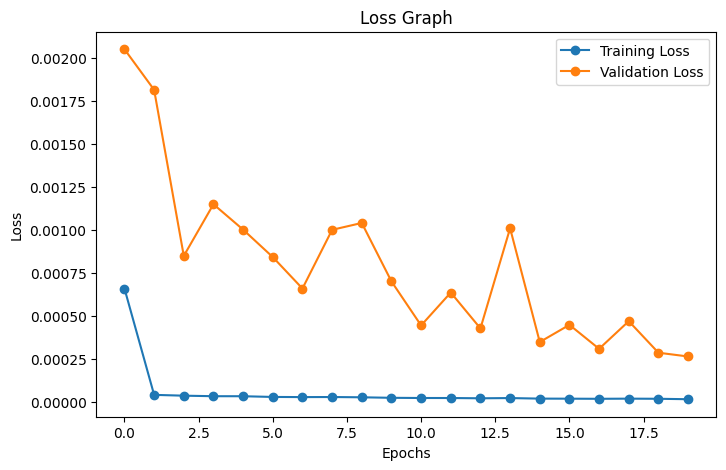

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    marker='o'
)

plt.plot(
    history.history['val_loss'],
    marker='o'
)

plt.title("Loss Graph")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()

In [ ]:
test_data = scaled_data[-100:]

x_test = []
y_test = data[-40:]

for i in range(60, len(test_data)):

    x_test.append(
        test_data[i-60:i,0]
    )

x_test = np.array(x_test)

In [ ]:
x_test = np.reshape(
    x_test,
    (x_test.shape[0],
     x_test.shape[1],
     1)
)

In [ ]:
predicted_prices = model.predict(x_test)

predicted_prices = scaler.inverse_transform(
    predicted_prices
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 768ms/step


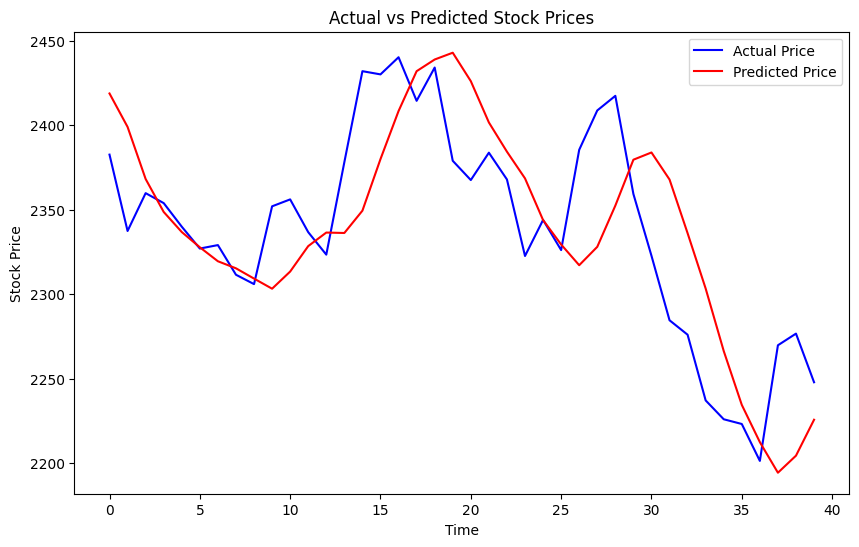

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    y_test,
    color='blue',
    label='Actual Price'
)

plt.plot(
    predicted_prices,
    color='red',
    label='Predicted Price'
)

plt.title("Actual vs Predicted Stock Prices")

plt.xlabel("Time")

plt.ylabel("Stock Price")

plt.legend()

plt.show()

In [ ]:
last_60_days = scaled_data[-60:]

future_input = last_60_days.reshape(
    1,60,1
)

future_predictions = []

for i in range(30):

    pred = model.predict(
        future_input,
        verbose=0
    )

    future_predictions.append(
        pred[0][0]
    )

    future_input = np.concatenate(
        (
            future_input[:,1:,:],
            pred.reshape(1,1,1)
        ),
        axis=1
    )

future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

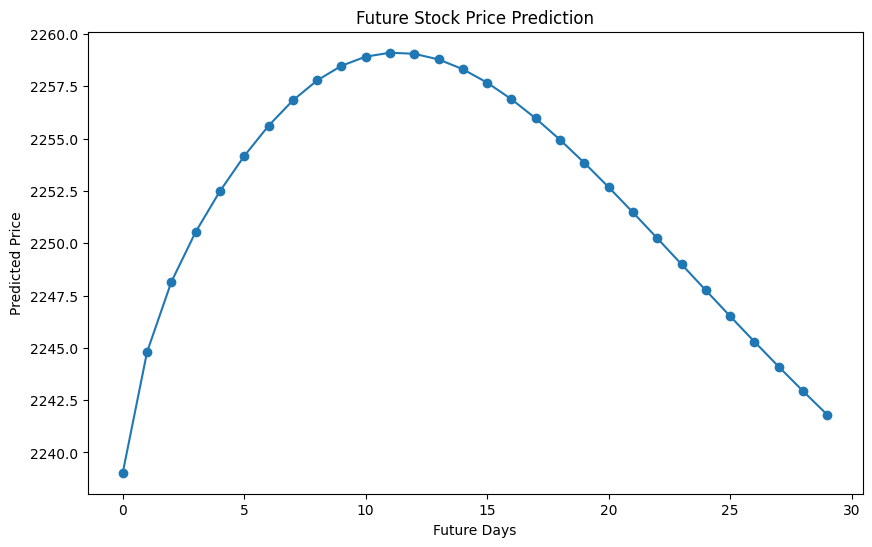

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    future_predictions,
    marker='o'
)

plt.title("Future Stock Price Prediction")

plt.xlabel("Future Days")

plt.ylabel("Predicted Price")

plt.show()